# 10-K NLP Scores — Full Analysis (Tracks 1 / 2 / 3 / 4)

**Course:** MACS 30113 — Large-Scale Computing for the Social Sciences  
**Author:** Yulin Wang, University of Chicago

**Research question:** Do more sophisticated NLP methods — neural sentiment (FinBERT), semantic novelty (Sentence-BERT), and LLM scoring (Llama-3.1-8B) — predict cumulative abnormal returns around 10-K filing dates better than the Loughran-McDonald dictionary baseline?

**Primary outcome:** `car_filed_1_1` — CAR[−1,+1] around `date_filed` (the date the 10-K is publicly available).  
**Robustness outcome:** `car_1_1` — CAR[−1,+1] around `rdq` (earnings announcement date).

**Pipeline:**  
`Section 1` Load data → `Section 2` Compute CARs → `Section 3` Merge tracks →  
`Section 4` Regressions → `Section 5` Causal ID (FD + IV) → `Section 6` Robustness

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json, glob
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
from scipy import stats as scipy_stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA = 'data'

## 1. Load Data

Load all raw inputs: financial panel, NLP scores from each track, CRSP returns.

In [2]:
# ── Financial panel + CRSP ───────────────────────────────────────────────────
panel   = pd.read_parquet(f'{DATA}/master_panel.parquet')
lm      = pd.read_parquet(f'{DATA}/lm_scores.parquet')
finbert = pd.read_parquet(f'{DATA}/finbert_scores.parquet')
embed   = pd.read_parquet(f'{DATA}/embed_similarity.parquet')
crsp    = pd.read_parquet(f'{DATA}/crsp_daily.parquet')
mkt     = pd.read_parquet(f'{DATA}/crsp_market.parquet')

panel['date_filed'] = pd.to_datetime(panel['date_filed'])
panel['rdq']        = pd.to_datetime(panel['rdq'])
crsp['date']        = pd.to_datetime(crsp['date'])
mkt['date']         = pd.to_datetime(mkt['date'])

print(f'Panel:   {len(panel):,} firm-years  |  {panel["ticker"].nunique():,} firms')
print(f'CRSP:    {len(crsp):,} daily obs')

# ── Track 3: Llama-3.1-8B scores (from SLURM job array output) ───────────────
records = []
for path in sorted(glob.glob(f'{DATA}/llm_out/results_*.jsonl')):
    with open(path) as f:
        for line in f:
            d = json.loads(line)
            if d['scores'] is not None:
                records.append({
                    'gvkey':           d['gvkey'],
                    'fyear':           int(d['fyear']),
                    'llm_optimism':    d['scores']['management_optimism'],
                    'llm_specificity': d['scores']['guidance_specificity'],
                    'llm_hedging':     d['scores']['uncertainty_hedging'],
                    'llm_risk':        d['scores']['risk_framing'],
                })
llama = pd.DataFrame(records)
print(f'Llama:   {len(llama):,} firm-years  |  parse success rate: {len(llama)/11269:.1%}')
llama.describe().round(2)

Panel:   11,269 firm-years  |  1,113 firms
CRSP:    3,488,808 daily obs
Llama:   11,269 firm-years  |  parse success rate: 100.0%


,fyear,llm_optimism,llm_specificity,llm_hedging,llm_risk
count,11269.00,11269.00,11269.00,11269.00,11268.00
mean,2015.17,5.72,3.28,4.33,3.10
std,3.14,1.71,2.55,2.28,1.95
min,2010.00,0.00,0.00,0.00,0.00
25%,2012.00,5.00,0.00,3.00,2.00
50%,2015.00,5.00,4.00,4.00,2.00
75%,2018.00,7.00,6.00,6.00,4.00
max,2020.00,9.00,9.00,10.00,10.00


## 2. Compute Cumulative Abnormal Returns (CAR)

**Primary outcome — `date_filed` window:** The 10-K is first publicly available on `date_filed`.
Market reactions in this window reflect investor processing of the MD&A text directly.

**Robustness outcome — `rdq` window:** The earnings announcement precedes the 10-K filing by
several weeks. CAR around `rdq` is included as a robustness check; any NLP predictability here
reflects text being correlated with underlying earnings quality, not a causal text effect.

CAR[lo, hi] = Σ (firm_return − market_return) over trading days [lo, hi] around the event date.

car_filed_1_1 loaded:  9,735 firm-years
Computing rdq CAR[-1,+1] ...
Computing rdq CAR[-3,+3] ...
car_1_1 (rdq):         11,230 firm-years


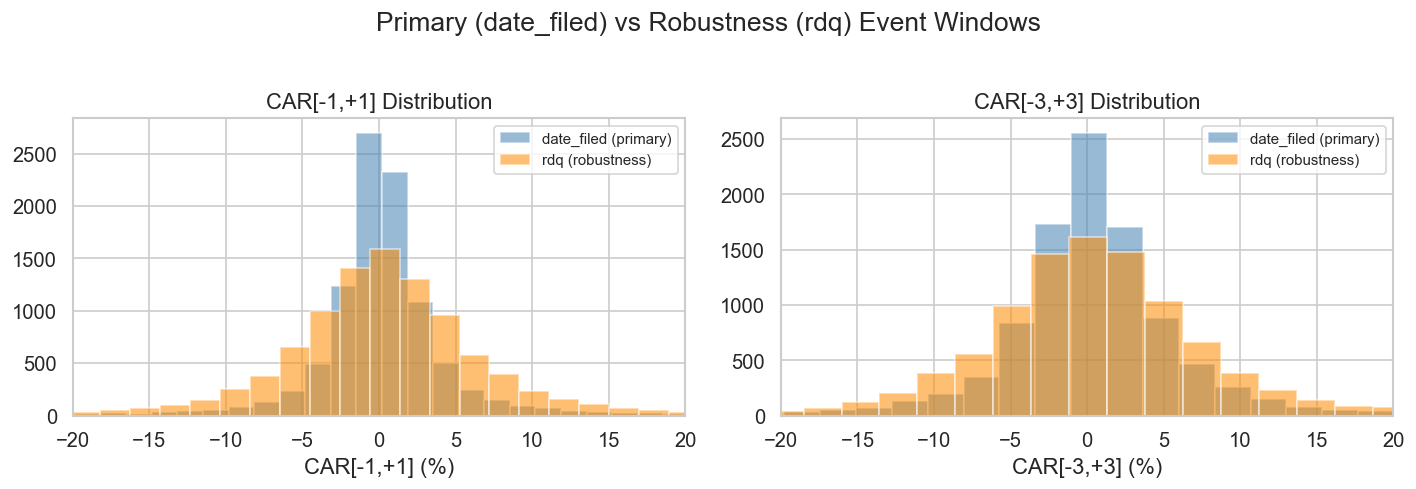

In [3]:
# Market-adjusted abnormal return
crsp = crsp.merge(mkt[['date', 'mkt_ret']], on='date', how='left')
crsp['abret']   = crsp['ret'] - crsp['mkt_ret']
crsp_sorted     = crsp.sort_values(['permno', 'date']).reset_index(drop=True)

def compute_car(panel_df, event_col, window=(-1, 1)):
    """Compute CAR for every firm-year given an event date column."""
    results = []
    for permno, grp in panel_df.groupby('permno'):
        firm_crsp = crsp_sorted[crsp_sorted['permno'] == permno].reset_index(drop=True)
        if firm_crsp.empty:
            results.extend([np.nan] * len(grp))
            continue
        dates = firm_crsp['date'].values
        for ev in grp[event_col].values:
            if pd.isna(ev):
                results.append(np.nan)
                continue
            idx  = np.searchsorted(dates, ev)
            lo, hi = idx + window[0], idx + window[1] + 1
            if lo < 0 or hi > len(dates):
                results.append(np.nan)
            else:
                results.append(firm_crsp.iloc[lo:hi]['abret'].sum())
    return results

# Primary: car_filed_1_1 (from pre-computed parquet — avoids re-running slow loop)
# compute_car_filing.py already produced this file
car_filed = pd.read_parquet(f'{DATA}/car_filing_date.parquet')
car_filed['fyear'] = car_filed['fyear'].astype(int)
print(f'car_filed_1_1 loaded:  {car_filed["car_filed_1_1"].notna().sum():,} firm-years')

# Robustness: car_1_1 / car_3_3 around rdq — computed inline from CRSP
panel_rdq = panel.dropna(subset=['rdq','permno']).sort_values(['permno','rdq']).reset_index(drop=True)
print('Computing rdq CAR[-1,+1] ...')
panel_rdq['car_1_1'] = compute_car(panel_rdq, 'rdq', (-1, 1))
print('Computing rdq CAR[-3,+3] ...')
panel_rdq['car_3_3'] = compute_car(panel_rdq, 'rdq', (-3, 3))
print(f'car_1_1 (rdq):         {panel_rdq["car_1_1"].notna().sum():,} firm-years')

# Distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, win in zip(axes, [('car_filed_1_1','car_1_1','[-1,+1]'),('car_filed_3_3','car_3_3','[-3,+3]')]):
    col_f, col_r, label = win
    merged_plot = car_filed.merge(panel_rdq[['gvkey','fyear',col_r]], on=['gvkey','fyear'], how='inner')
    ax.hist(merged_plot[col_f]*100, bins=60, alpha=0.55, label='date_filed (primary)', color='steelblue')
    ax.hist(merged_plot[col_r]*100, bins=60, alpha=0.55, label='rdq (robustness)',    color='darkorange')
    ax.set_xlabel(f'CAR{label} (%)')
    ax.set_title(f'CAR{label} Distribution')
    ax.legend(fontsize=9)
    ax.set_xlim(-20, 20)
plt.suptitle('Primary (date_filed) vs Robustness (rdq) Event Windows', y=1.02)
plt.tight_layout()
plt.show()

## 3. Merge All Tracks

Join Tracks 1/2/3/4 features, CAR outcomes, and financial controls into a single analysis panel.

In [4]:
df = (panel_rdq
      .merge(lm,       on=['gvkey','fyear'], how='left')
      .merge(finbert,  on=['gvkey','fyear'], how='left')
      .merge(embed,    on=['gvkey','fyear'], how='left')
      .merge(llama,    on=['gvkey','fyear'], how='left')
      .merge(car_filed,on=['gvkey','fyear'], how='left'))

print(f'Merged panel:      {len(df):,} firm-years')
print(f'Unique firms:      {df["gvkey"].nunique():,}')
print(f'Track 1 (LM):      {df["lm_tone"].notna().sum():,}')
print(f'Track 2 (FinBERT): {df["fb_net"].notna().sum():,}')
print(f'Track 3 (Llama):   {df["llm_optimism"].notna().sum():,}')
print(f'Track 4 (SBERT):   {df["embed_novelty"].notna().sum():,}')
print(f'car_filed_1_1:     {df["car_filed_1_1"].notna().sum():,}')
print(f'car_1_1 (rdq):     {df["car_1_1"].notna().sum():,}')

Merged panel:      11,263 firm-years
Unique firms:      1,113
Track 1 (LM):      10,837
Track 2 (FinBERT): 11,263
Track 3 (Llama):   11,263
Track 4 (SBERT):   10,154
car_filed_1_1:     9,735
car_1_1 (rdq):     11,230


## 4. Z-score Standardize & Build Regression Sample

All NLP and control variables are z-score standardized so regression coefficients are directly comparable across tracks (each β = effect of a 1-SD increase in the NLP measure).

In [5]:
TEXT_124 = ['lm_tone','lm_uncertainty_pct','fb_net','embed_novelty']
TEXT_LLM = ['llm_optimism','llm_specificity','llm_hedging','llm_risk']
CONTROLS = ['log_assets','log_mktcap','bm_ratio','roa','leverage']
ALL_VARS = TEXT_124 + TEXT_LLM + CONTROLS

for col in ALL_VARS:
    if col in df.columns:
        df[f'{col}_z'] = stats.zscore(df[col], nan_policy='omit')

df['sic2']     = df['sic'].astype(str).str[:2]
df['fyear']    = df['fyear'].astype(int)
df['fyear_str']= df['fyear'].astype(str)

# Primary regression sample — requires car_filed_1_1 + all NLP + controls
REG_VARS = ['car_filed_1_1'] + [f'{c}_z' for c in ALL_VARS]
df_reg   = df.dropna(subset=REG_VARS).copy()
df_reg['fyear'] = df_reg['fyear'].astype(str)

print(f'Primary regression sample (car_filed_1_1): {len(df_reg):,} firm-years')
print(f'Unique firms: {df_reg["gvkey"].nunique():,}')
print()
df_reg[['car_filed_1_1','lm_tone','fb_net','embed_novelty','llm_optimism']].describe().round(4)

Primary regression sample (car_filed_1_1): 9,735 firm-years
Unique firms: 1,093



,car_filed_1_1,lm_tone,fb_net,embed_novelty,llm_optimism
count,9735.0000,9735.0000,9735.0000,9735.0000,9735.0000
mean,0.0023,-0.3949,-0.1072,0.0356,5.8011
std,0.0459,0.2657,0.1444,0.0693,1.6703
min,-0.4657,-1.0000,-0.9037,-0.0000,0.0000
25%,-0.0143,-0.5642,-0.1991,0.0110,5.0000
50%,0.0007,-0.4091,-0.0966,0.0159,6.0000
75%,0.0177,-0.2414,-0.0150,0.0260,8.0000
max,0.5364,1.0000,0.7805,0.8410,9.0000


## 5. Descriptive Statistics

### 5a. Llama Score Distributions
### 5b. Correlation Matrix — All Tracks

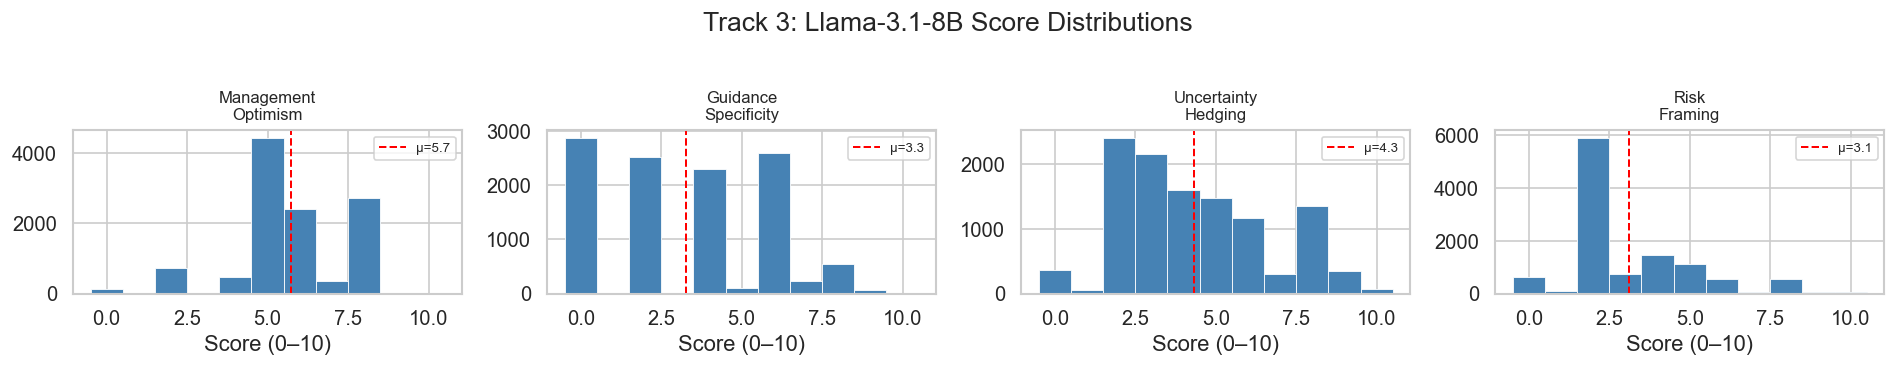

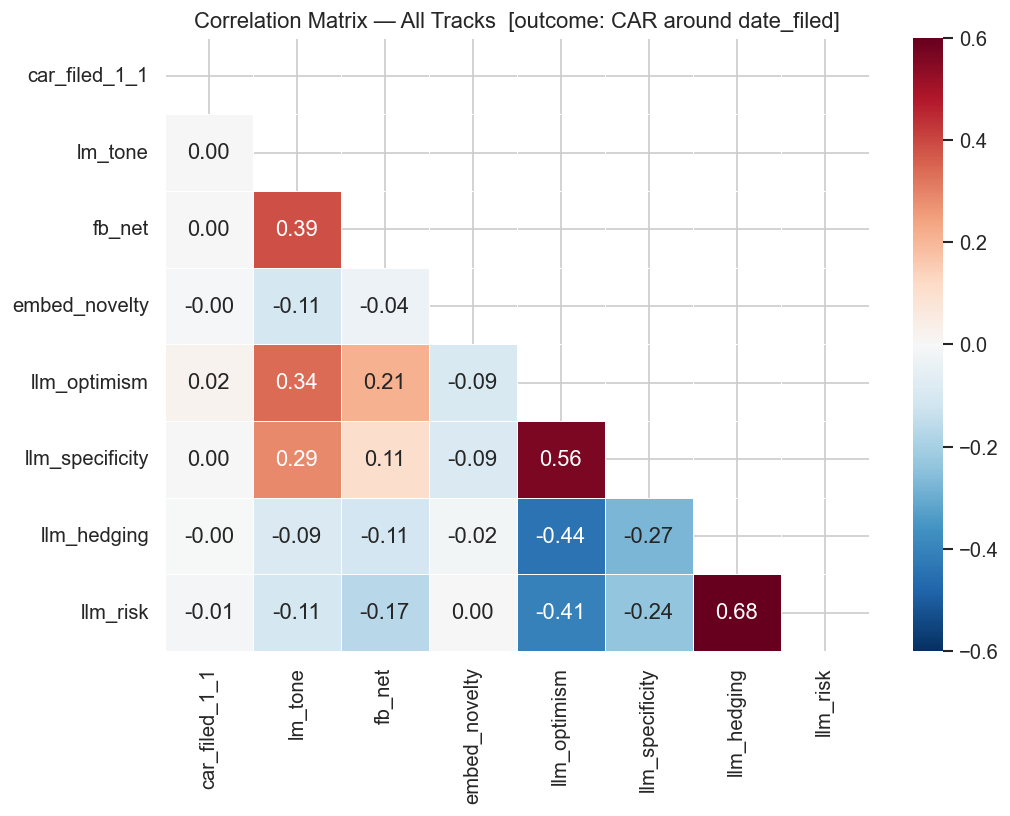

In [6]:
# Llama score distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, col, label in zip(axes,
    ['llm_optimism','llm_specificity','llm_hedging','llm_risk'],
    ['Management\nOptimism','Guidance\nSpecificity','Uncertainty\nHedging','Risk\nFraming']):
    ax.hist(llama[col], bins=11, range=(-0.5,10.5), color='steelblue', edgecolor='white', lw=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Score (0–10)')
    ax.axvline(llama[col].mean(), color='red', ls='--', lw=1.2, label=f'μ={llama[col].mean():.1f}')
    ax.legend(fontsize=8)
plt.suptitle('Track 3: Llama-3.1-8B Score Distributions', y=1.02)
plt.tight_layout()
plt.show()

# Correlation heatmap
corr_vars = ['car_filed_1_1','lm_tone','fb_net','embed_novelty',
             'llm_optimism','llm_specificity','llm_hedging','llm_risk']
corr = df_reg[[v for v in corr_vars if v in df_reg.columns]].corr()
fig, ax = plt.subplots(figsize=(9,7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.6, vmax=0.6, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — All Tracks  [outcome: CAR around date_filed]')
plt.tight_layout()
plt.show()

## 6. OLS Regressions — Four Tracks + Horse-Race

All models: OLS with industry (2-digit SIC) + year fixed effects, firm-clustered SEs,
z-score standardized NLP variables. **Primary outcome: `car_filed_1_1`.**

| Model | Content |
|-------|---------|
| M1 | Track 1 only — LM Dictionary |
| M2 | Track 2 only — FinBERT |
| M3 | Track 3 only — Llama-3.1-8B |
| M4 | Track 4 only — Sentence-BERT Novelty |
| MC | Horse-race — all 8 NLP variables simultaneously |
| MD | Robustness — MC with wider window CAR[−3,+3] |

In [7]:
CTRL_Z = ' + '.join(f'{c}_z' for c in CONTROLS)
FE     = 'C(fyear) + C(sic2)'

def run_ols(formula, data):
    return smf.ols(formula, data=data).fit(
        cov_type='cluster', cov_kwds={'groups': data['gvkey']})

def show_model(model, name, text_vars):
    rows = []
    for var in text_vars:
        if var not in model.params: continue
        p = model.pvalues[var]
        stars = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
        rows.append({'Variable':var,'Coef':round(model.params[var],4),
                     'SE':round(model.bse[var],4),'t':round(model.tvalues[var],2),
                     'p':round(p,4),'Sig':stars})
    tbl = pd.DataFrame(rows).set_index('Variable')
    print(f'\n── {name}  |  R²={model.rsquared:.4f}  N={int(model.nobs):,} ──')
    print(tbl.to_string())
    return tbl

In [8]:
# M1: Track 1 — LM Dictionary (word-bag baseline)
# Oldest approach: count positive/negative financial words in Loughran-McDonald lexicon.
lm_vars = 'lm_tone_z + lm_uncertainty_pct_z'
mM1 = run_ols(f'car_filed_1_1 ~ {lm_vars} + {CTRL_Z} + {FE}', df_reg)
tM1 = show_model(mM1, 'M1: Track 1 — LM Dictionary  [outcome: CAR around date_filed]',
                 ['lm_tone_z','lm_uncertainty_pct_z'])


── M1: Track 1 — LM Dictionary  [outcome: CAR around date_filed]  |  R²=0.0135  N=9,735 ──
                        Coef      SE     t       p Sig
Variable                                              
lm_tone_z             0.0003  0.0005  0.59  0.5573    
lm_uncertainty_pct_z  0.0009  0.0005  1.57  0.1155    


In [9]:
# M2: Track 2 — FinBERT neural sentiment
# Fine-tuned BERT for financial text; understands context and negation.
mM2 = run_ols(f'car_filed_1_1 ~ fb_net_z + {CTRL_Z} + {FE}', df_reg)
tM2 = show_model(mM2, 'M2: Track 2 — FinBERT  [outcome: CAR around date_filed]',
                 ['fb_net_z'])


── M2: Track 2 — FinBERT  [outcome: CAR around date_filed]  |  R²=0.0133  N=9,735 ──
            Coef      SE     t       p Sig
Variable                                  
fb_net_z  0.0004  0.0005  0.76  0.4491    


In [10]:
# M3: Track 3 — Llama-3.1-8B multidimensional scoring
# LLM scores four theory-driven dimensions beyond simple sentiment.
llm_vars = 'llm_optimism_z + llm_specificity_z + llm_hedging_z + llm_risk_z'
mM3 = run_ols(f'car_filed_1_1 ~ {llm_vars} + {CTRL_Z} + {FE}', df_reg)
tM3 = show_model(mM3, 'M3: Track 3 — Llama-3.1-8B  [outcome: CAR around date_filed]',
                 ['llm_optimism_z','llm_specificity_z','llm_hedging_z','llm_risk_z'])


── M3: Track 3 — Llama-3.1-8B  [outcome: CAR around date_filed]  |  R²=0.0135  N=9,735 ──
                     Coef      SE     t       p Sig
Variable                                           
llm_optimism_z     0.0009  0.0007  1.26  0.2091    
llm_specificity_z -0.0003  0.0006 -0.56  0.5739    
llm_hedging_z      0.0002  0.0007  0.25  0.8001    
llm_risk_z        -0.0003  0.0007 -0.40  0.6873    


In [11]:
# M4: Track 4 — Sentence-BERT semantic novelty
# Year-over-year change in MD&A content (cosine distance of SBERT embeddings).
mM4 = run_ols(f'car_filed_1_1 ~ embed_novelty_z + {CTRL_Z} + {FE}', df_reg)
tM4 = show_model(mM4, 'M4: Track 4 — SBERT Novelty  [outcome: CAR around date_filed]',
                 ['embed_novelty_z'])


── M4: Track 4 — SBERT Novelty  [outcome: CAR around date_filed]  |  R²=0.0133  N=9,735 ──
                   Coef      SE     t       p Sig
Variable                                         
embed_novelty_z -0.0002  0.0004 -0.48  0.6282    


In [12]:
# MC: Horse-Race — all 8 NLP variables compete simultaneously
# A variable remaining significant here carries information orthogonal to all others.
all_vars = f'{lm_vars} + fb_net_z + embed_novelty_z + {llm_vars}'
mC = run_ols(f'car_filed_1_1 ~ {all_vars} + {CTRL_Z} + {FE}', df_reg)
tC = show_model(mC, 'MC: Horse-Race — All Tracks 1+2+3+4  [outcome: CAR around date_filed]',
                ['lm_tone_z','lm_uncertainty_pct_z','fb_net_z','embed_novelty_z',
                 'llm_optimism_z','llm_specificity_z','llm_hedging_z','llm_risk_z'])


── MC: Horse-Race — All Tracks 1+2+3+4  [outcome: CAR around date_filed]  |  R²=0.0139  N=9,735 ──
                        Coef      SE     t       p Sig
Variable                                              
lm_tone_z            -0.0000  0.0005 -0.01  0.9957    
lm_uncertainty_pct_z  0.0010  0.0006  1.87  0.0618   *
fb_net_z              0.0003  0.0005  0.52  0.5998    
embed_novelty_z      -0.0003  0.0004 -0.62  0.5329    
llm_optimism_z        0.0009  0.0007  1.28  0.2003    
llm_specificity_z    -0.0004  0.0006 -0.60  0.5510    
llm_hedging_z         0.0001  0.0007  0.10  0.9168    
llm_risk_z           -0.0003  0.0007 -0.48  0.6342    


In [13]:
# MD: Wider event window CAR[-3,+3] around date_filed
df_rob = df.dropna(subset=['car_filed_3_3'] + [f'{c}_z' for c in ALL_VARS]).copy()
df_rob['fyear'] = df_rob['fyear'].astype(str)
mD = run_ols(f'car_filed_3_3 ~ {all_vars} + {CTRL_Z} + {FE}', df_rob)
tD = show_model(mD, 'MD: Wider window CAR[-3,+3] around date_filed (all tracks)',
                ['lm_tone_z','lm_uncertainty_pct_z','fb_net_z','embed_novelty_z',
                 'llm_optimism_z','llm_specificity_z','llm_hedging_z','llm_risk_z'])


── MD: Wider window CAR[-3,+3] around date_filed (all tracks)  |  R²=0.0250  N=9,735 ──
                        Coef      SE     t       p Sig
Variable                                              
lm_tone_z            -0.0001  0.0007 -0.16  0.8705    
lm_uncertainty_pct_z  0.0009  0.0007  1.33  0.1843    
fb_net_z              0.0008  0.0007  1.12  0.2628    
embed_novelty_z      -0.0003  0.0006 -0.45  0.6545    
llm_optimism_z        0.0010  0.0009  1.06  0.2890    
llm_specificity_z    -0.0006  0.0008 -0.67  0.5055    
llm_hedging_z         0.0007  0.0009  0.81  0.4202    
llm_risk_z           -0.0010  0.0010 -1.01  0.3140    


R² Comparison [outcome: CAR[-1,+1] around date_filed]
                         Track  R² (%)     N
Model                                       
M1: LM Dictionary           T1   1.351  9735
M2: FinBERT                 T2   1.331  9735
M3: Llama                   T3   1.351  9735
M4: SBERT Novelty           T4   1.328  9735
MC: Horse-Race (all)  T1+2+3+4   1.389  9735


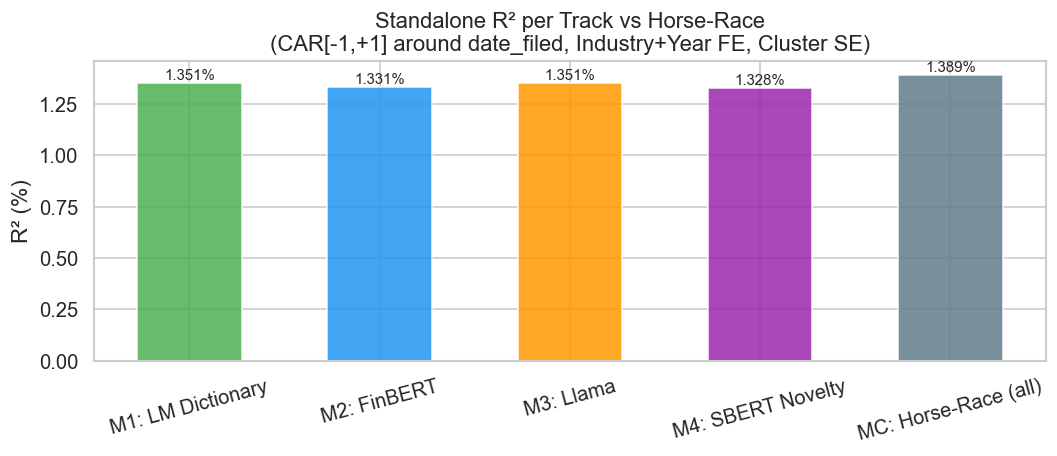

In [14]:
# R² comparison: standalone vs horse-race
r2_tbl = pd.DataFrame([
    {'Model':'M1: LM Dictionary',    'Track':'T1',       'R²':mM1.rsquared,'N':int(mM1.nobs)},
    {'Model':'M2: FinBERT',          'Track':'T2',       'R²':mM2.rsquared,'N':int(mM2.nobs)},
    {'Model':'M3: Llama',            'Track':'T3',       'R²':mM3.rsquared,'N':int(mM3.nobs)},
    {'Model':'M4: SBERT Novelty',    'Track':'T4',       'R²':mM4.rsquared,'N':int(mM4.nobs)},
    {'Model':'MC: Horse-Race (all)', 'Track':'T1+2+3+4', 'R²':mC.rsquared, 'N':int(mC.nobs)},
]).set_index('Model')
r2_tbl['R² (%)'] = (r2_tbl['R²'] * 100).round(3)
print("R² Comparison [outcome: CAR[-1,+1] around date_filed]")
print(r2_tbl[['Track','R² (%)','N']].to_string())

fig, ax = plt.subplots(figsize=(9,4))
colors = ['#4CAF50','#2196F3','#FF9800','#9C27B0','#607D8B']
bars = ax.bar(r2_tbl.index, r2_tbl['R² (%)'], color=colors, alpha=0.85, width=0.55)
for bar, (_, row) in zip(bars, r2_tbl.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f"{row['R² (%)']:.3f}%", ha='center', va='bottom', fontsize=9)
ax.set_ylabel('R² (%)')
ax.set_title('Standalone R² per Track vs Horse-Race\n(CAR[-1,+1] around date_filed, Industry+Year FE, Cluster SE)')
ax.tick_params(axis='x', labelrotation=15)
plt.tight_layout()
plt.show()

## 7. Incremental F-test: Does Track 3 (Llama) Add Explanatory Power?

Tests whether the 4 Llama variables jointly improve fit over T1+T2+T4 alone.
**H₀:** β_llm_optimism = β_llm_specificity = β_llm_hedging = β_llm_risk = 0

In [15]:
t124_vars_ft = 'lm_tone_z + lm_uncertainty_pct_z + fb_net_z + embed_novelty_z'
mRestr = run_ols(f'car_filed_1_1 ~ {t124_vars_ft} + {CTRL_Z} + {FE}', df_reg)

RSS_R = mRestr.ssr; RSS_U = mC.ssr
df_R  = mRestr.df_resid; df_U = mC.df_resid
q     = df_R - df_U     # 4 Llama variables
F_stat = ((RSS_R - RSS_U) / q) / (RSS_U / df_U)
p_val  = 1 - scipy_stats.f.cdf(F_stat, q, df_U)

print("Incremental F-test: Track 3 (Llama) added over T1+T2+T4")
print(f"  Outcome: CAR[-1,+1] around date_filed  |  N = {int(mRestr.nobs):,}")
print(f"  Restricted  (T1+T2+T4): R² = {mRestr.rsquared:.4f}")
print(f"  Unrestricted (all):     R² = {mC.rsquared:.4f}")
print(f"  F({int(q)}, {int(df_U)}) = {F_stat:.3f},  p = {p_val:.4f}")
star = '***' if p_val<0.01 else '**' if p_val<0.05 else '*' if p_val<0.10 else '(n.s.)'
print(f"  → {'Llama adds significant power' if p_val<0.10 else 'No significant gain from Llama'}  {star}")

# Reverse: does T1+T2+T4 add over Llama alone?
RSS_R2=mM3.ssr; df_R2=mM3.df_resid; q2=df_R2-df_U
F2 = ((RSS_R2-RSS_U)/q2)/(RSS_U/df_U)
p2 = 1 - scipy_stats.f.cdf(F2, q2, df_U)
star2 = '***' if p2<0.01 else '**' if p2<0.05 else '*' if p2<0.10 else '(n.s.)'
print(f"\nReverse test: T1+T2+T4 added over Llama alone")
print(f"  F({int(q2)}, {int(df_U)}) = {F2:.3f},  p = {p2:.4f}  {star2}")

Incremental F-test: Track 3 (Llama) added over T1+T2+T4
  Outcome: CAR[-1,+1] around date_filed  |  N = 9,735
  Restricted  (T1+T2+T4): R² = 0.0136
  Unrestricted (all):     R² = 0.0139
  F(4, 9651) = 0.735,  p = 0.5677
  → No significant gain from Llama  (n.s.)

Reverse test: T1+T2+T4 added over Llama alone
  F(4, 9651) = 0.918,  p = 0.4521  (n.s.)


## 8. Coefficient Plot — All Tracks (Model MC)

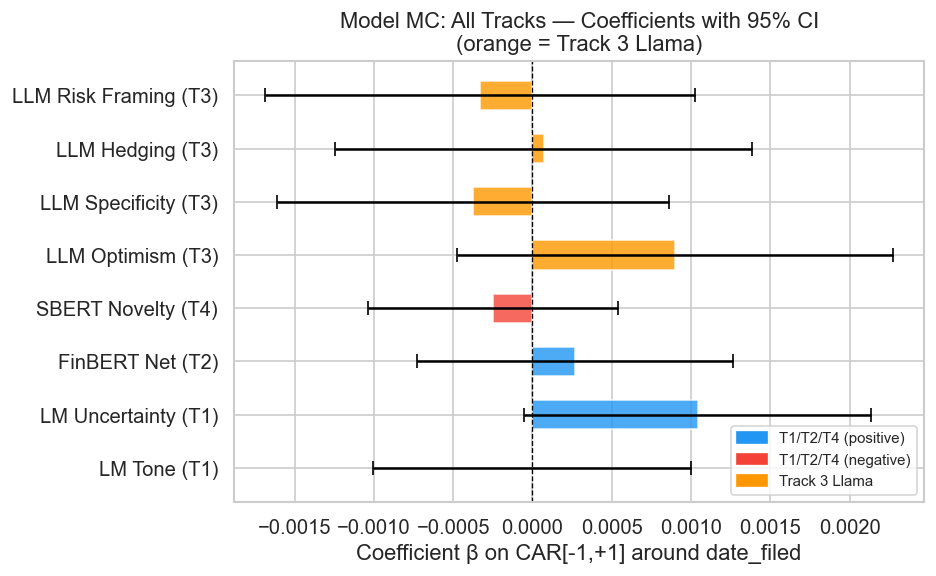

In [16]:
plot_vars = [
    ('lm_tone_z',           'LM Tone (T1)'),
    ('lm_uncertainty_pct_z','LM Uncertainty (T1)'),
    ('fb_net_z',            'FinBERT Net (T2)'),
    ('embed_novelty_z',     'SBERT Novelty (T4)'),
    ('llm_optimism_z',      'LLM Optimism (T3)'),
    ('llm_specificity_z',   'LLM Specificity (T3)'),
    ('llm_hedging_z',       'LLM Hedging (T3)'),
    ('llm_risk_z',          'LLM Risk Framing (T3)'),
]
vars_   = [v for v,_ in plot_vars if v in mC.params]
labels_ = [l for v,l in plot_vars if v in mC.params]
coefs_  = mC.params[vars_]
cis_    = mC.conf_int().loc[vars_]

fig, ax = plt.subplots(figsize=(8,5))
for i, (var, label) in enumerate(zip(vars_, labels_)):
    color = '#FF9800' if var.startswith('llm') else ('#2196F3' if coefs_[var]>0 else '#F44336')
    ax.barh(i, coefs_[var], color=color, alpha=0.8, height=0.55)
    ax.errorbar(coefs_[var], i,
                xerr=[[coefs_[var]-cis_.loc[var,0]],[cis_.loc[var,1]-coefs_[var]]],
                fmt='none', color='black', capsize=4, lw=1.5)
ax.set_yticks(range(len(labels_))); ax.set_yticklabels(labels_)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Coefficient β on CAR[-1,+1] around date_filed')
ax.set_title('Model MC: All Tracks — Coefficients with 95% CI\n(orange = Track 3 Llama)')
legend = [Patch(color='#2196F3',label='T1/T2/T4 (positive)'),
          Patch(color='#F44336',label='T1/T2/T4 (negative)'),
          Patch(color='#FF9800',label='Track 3 Llama')]
ax.legend(handles=legend, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 9. CAR by Llama Score Group

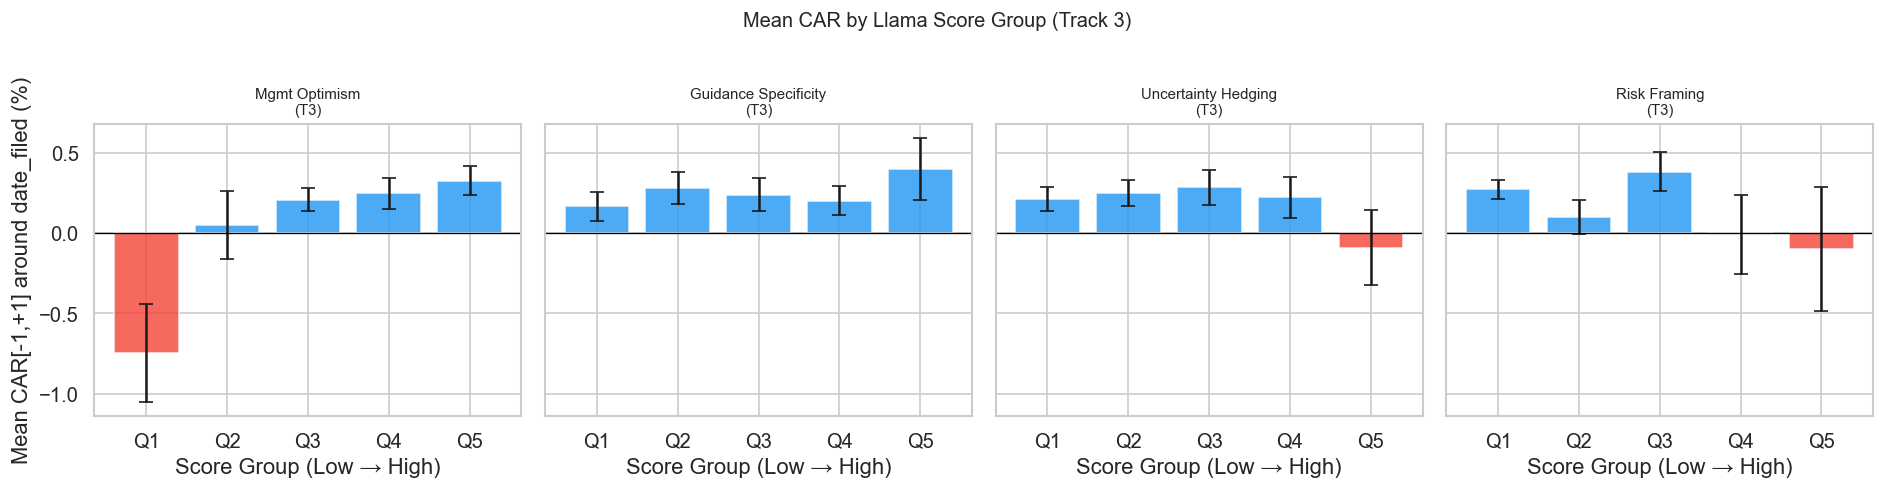

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(16,4), sharey=True)
for ax, var, label in zip(axes,
    ['llm_optimism','llm_specificity','llm_hedging','llm_risk'],
    ['Mgmt Optimism\n(T3)','Guidance Specificity\n(T3)',
     'Uncertainty Hedging\n(T3)','Risk Framing\n(T3)']):
    df_plot = df_reg.dropna(subset=[var,'car_filed_1_1']).copy()
    df_plot['score_grp'] = pd.cut(df_plot[var], bins=5, include_lowest=True)
    means = df_plot.groupby('score_grp', observed=True)['car_filed_1_1'].mean() * 100
    sems  = df_plot.groupby('score_grp', observed=True)['car_filed_1_1'].sem()  * 100
    colors = ['#F44336' if m<0 else '#2196F3' for m in means]
    ax.bar(range(len(means)), means, yerr=sems, color=colors,
           alpha=0.8, edgecolor='white', capsize=4)
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels([f'Q{i+1}' for i in range(len(means))])
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Score Group (Low → High)')
    if ax == axes[0]:
        ax.set_ylabel('Mean CAR[-1,+1] around date_filed (%)')
plt.suptitle('Mean CAR by Llama Score Group (Track 3)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 10. Save Results

In [18]:
all_results = []
for tbl, name in [(tM1,'M1: LM Dict'),(tM2,'M2: FinBERT'),
                  (tM3,'M3: Llama'),(tM4,'M4: SBERT'),
                  (tC,'MC: Horse-Race'),(tD,'MD: CAR[-3,+3]')]:
    t = tbl.copy(); t['Model'] = name
    all_results.append(t.reset_index())

out = pd.concat(all_results, ignore_index=True)
out.to_csv(f'{DATA}/regression_results_1234.csv', index=False)
print('✓ Saved regression_results_1234.csv')

df_reg.to_parquet(f'{DATA}/analysis_panel_1234.parquet', index=False)
print('✓ Saved analysis_panel_1234.parquet')

✓ Saved regression_results_1234.csv
✓ Saved analysis_panel_1234.parquet


## 11. Multicollinearity Check (VIF)

All NLP variables should show VIF < 5. High VIF (>10) would indicate that one variable is nearly a linear combination of others, making coefficient estimates unstable.

In [19]:
text_z_cols = ['lm_tone_z','lm_uncertainty_pct_z','fb_net_z','embed_novelty_z',
               'llm_optimism_z','llm_specificity_z','llm_hedging_z','llm_risk_z']
X_vif = df_reg[text_z_cols].dropna().assign(const=1.0)
vif_df = pd.DataFrame({
    'Variable': text_z_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(text_z_cols))]
}).set_index('Variable').round(2)
print("VIF (< 2 = excellent | < 5 = good | > 10 = concern)")
print(vif_df.to_string())
print(f"\nMax VIF: {vif_df['VIF'].max():.2f}  — {'✓ No multicollinearity concern' if vif_df['VIF'].max()<5 else '⚠ Check collinearity'}")

VIF (< 2 = excellent | < 5 = good | > 10 = concern)
                       VIF
Variable                  
lm_tone_z             1.35
lm_uncertainty_pct_z  1.09
fb_net_z              1.21
embed_novelty_z       1.03
llm_optimism_z        1.84
llm_specificity_z     1.50
llm_hedging_z         1.99
llm_risk_z            1.92

Max VIF: 1.99  — ✓ No multicollinearity concern


## 12. Causal Identification — First Difference

**Motivation:** OLS with industry+year FE removes time-invariant firm effects and common shocks,
but cannot rule out *time-varying* firm-level confounders (e.g., a firm whose management
persistently becomes more optimistic as the firm's fundamentals improve).

**First-difference strategy:** Regress Δ(CAR_filed) on Δ(NLP scores) and Δ(Controls).
Taking first differences removes *all* time-invariant firm-level heterogeneity, including
persistent management style, industry position, or analyst following.

**Both sides must be differenced:** Δy ~ ΔX, not y ~ ΔX. Using level outcome with
differenced predictors introduces a mechanical negative autocorrelation bias.

In [20]:
# Restrict to firm-years with valid primary outcome before differencing
# (mirrors analysis_track1234 starting point; keeps FD sample consistent with regression sample)
df_fd = df[df["car_filed_1_1"].notna()].copy()
df_fd['fyear'] = df_fd['fyear'].astype(int)
df_fd['sic2']  = df_fd['sic'].astype(str).str[:2]
df_fd = df_fd.sort_values(['gvkey','fyear'])

diff_cols = ['car_filed_1_1',
             'lm_tone','lm_uncertainty_pct','fb_net','embed_novelty',
             'llm_optimism','llm_specificity','llm_hedging','llm_risk',
             'log_assets','log_mktcap','bm_ratio','roa','leverage']

for col in diff_cols:
    if col in df_fd.columns:
        df_fd[f'd_{col}'] = df_fd.groupby('gvkey')[col].diff()

key_diff = ['car_filed_1_1','fb_net','llm_optimism','llm_hedging',
            'lm_tone','embed_novelty','log_assets','log_mktcap','bm_ratio','roa','leverage']
df_fd = df_fd.dropna(subset=[f'd_{c}' for c in key_diff])

for col in diff_cols:
    if f'd_{col}' in df_fd.columns:
        df_fd[f'd_{col}_z'] = stats.zscore(df_fd[f'd_{col}'], nan_policy='omit')

df_fd['fyear_str'] = df_fd['fyear'].astype(str)
print(f'First-difference sample: {len(df_fd):,} firm-year transitions')
print(f'Unique firms: {df_fd["gvkey"].nunique():,}')

First-difference sample: 8,642 firm-year transitions
Unique firms: 1,077


In [21]:
d_llm  = 'd_llm_optimism_z + d_llm_specificity_z + d_llm_hedging_z + d_llm_risk_z'
d_t124 = 'd_lm_tone_z + d_lm_uncertainty_pct_z + d_fb_net_z + d_embed_novelty_z'
d_ctrl = 'd_log_assets_z + d_log_mktcap_z + d_bm_ratio_z + d_roa_z + d_leverage_z'
FE_fd  = 'C(fyear_str)'

def run_fd(formula, data):
    return smf.ols(formula, data=data).fit(
        cov_type='cluster', cov_kwds={'groups': data['gvkey']})

mFD_A = run_fd(f'd_car_filed_1_1_z ~ {d_llm} + {d_ctrl} + {FE_fd}', df_fd)
tFD_A = show_model(mFD_A, 'FD-A: First Diff — Llama only  [Δ(CAR_filed)]',
                   ['d_llm_optimism_z','d_llm_specificity_z','d_llm_hedging_z','d_llm_risk_z'])

mFD_B = run_fd(f'd_car_filed_1_1_z ~ {d_llm} + {d_t124} + {d_ctrl} + {FE_fd}', df_fd)
tFD_B = show_model(mFD_B, 'FD-B: First Diff — All Tracks  [Δ(CAR_filed)]',
                   ['d_lm_tone_z','d_lm_uncertainty_pct_z','d_fb_net_z','d_embed_novelty_z',
                    'd_llm_optimism_z','d_llm_specificity_z','d_llm_hedging_z','d_llm_risk_z'])


── FD-A: First Diff — Llama only  [Δ(CAR_filed)]  |  R²=0.0167  N=8,642 ──
                       Coef      SE     t       p  Sig
Variable                                              
d_llm_optimism_z     0.0386  0.0147  2.63  0.0086  ***
d_llm_specificity_z -0.0032  0.0146 -0.22  0.8276     
d_llm_hedging_z      0.0077  0.0153  0.51  0.6115     
d_llm_risk_z        -0.0014  0.0148 -0.10  0.9220     

── FD-B: First Diff — All Tracks  [Δ(CAR_filed)]  |  R²=0.0168  N=8,642 ──
                          Coef      SE     t       p  Sig
Variable                                                 
d_lm_tone_z            -0.0084  0.0127 -0.66  0.5087     
d_lm_uncertainty_pct_z  0.0016  0.0099  0.16  0.8714     
d_fb_net_z              0.0059  0.0137  0.43  0.6654     
d_embed_novelty_z      -0.0000  0.0120 -0.00  0.9975     
d_llm_optimism_z        0.0395  0.0151  2.63  0.0086  ***
d_llm_specificity_z    -0.0025  0.0145 -0.17  0.8649     
d_llm_hedging_z         0.0079  0.0153  0.52  0.6061  

## 13. Exploratory: IV / 2SLS

**Instrument:** Leave-one-out industry-year peer mean `llm_optimism` — the average optimism
score of all other firms in the same 2-digit SIC × year cell.

**Relevance:** Strong — industry peers' optimism predicts a firm's own optimism (F >> 10).

**⚠ Exclusion restriction caveat:** The instrument may not be valid because industry-wide
conditions that drive peer optimism can *also* directly affect a firm's filing-date CAR via
real economic channels (industry tailwinds, sector rotation), bypassing the text channel.
Results should be treated as directional evidence only, not as clean causal estimates.

In [22]:
df_iv = df_reg.copy()
df_iv['fyear'] = df_iv['fyear'].astype(int)

for col in ['llm_optimism','fb_net','lm_tone']:
    grp_sum   = df_iv.groupby(['sic2','fyear'])[col].transform('sum')
    grp_count = df_iv.groupby(['sic2','fyear'])[col].transform('count')
    df_iv[f'{col}_loo'] = (grp_sum - df_iv[col]) / (grp_count - 1)

from scipy.stats import pearsonr
valid = df_iv[['llm_optimism','llm_optimism_loo']].dropna()
r, p  = pearsonr(valid['llm_optimism'], valid['llm_optimism_loo'])
print(f"LOO instrument — Pearson r = {r:.3f}  (p = {p:.2e})")
print("Note: strong relevance expected; exclusion restriction is the binding assumption.")

for col in ['llm_optimism','fb_net','lm_tone']:
    df_iv[f'{col}_loo_z'] = stats.zscore(df_iv[f'{col}_loo'], nan_policy='omit')

df_iv['fyear_str'] = df_iv['fyear'].astype(str)
iv_req = ['car_filed_1_1','llm_optimism_z','llm_optimism_loo_z',
          'fb_net_z','lm_tone_z','embed_novelty_z',
          'log_assets_z','log_mktcap_z','bm_ratio_z','roa_z','leverage_z']
df_iv2 = df_iv.dropna(subset=iv_req).copy()
print(f"IV sample: {len(df_iv2):,} firm-years")

LOO instrument — Pearson r = 0.181  (p = 1.03e-72)
Note: strong relevance expected; exclusion restriction is the binding assumption.
IV sample: 9,714 firm-years


In [23]:
CTRL_Z = ' + '.join(f'{c}_z' for c in CONTROLS)
FE_iv  = 'C(fyear_str) + C(sic2)'

fs = smf.ols(
    f'llm_optimism_z ~ llm_optimism_loo_z + {CTRL_Z} + {FE_iv}',
    data=df_iv2).fit()
df_iv2['llm_optimism_hat'] = fs.fittedvalues

fs_r   = smf.ols(f'llm_optimism_z ~ {CTRL_Z} + {FE_iv}', data=df_iv2).fit()
f_stat = ((fs_r.ssr - fs.ssr) / 1) / (fs.ssr / fs.df_resid)
print(f"First-stage F = {f_stat:.2f}  (relevance: strong if >> 10)")

mIV = smf.ols(
    f'car_filed_1_1 ~ llm_optimism_hat + fb_net_z + lm_tone_z + embed_novelty_z + {CTRL_Z} + {FE_iv}',
    data=df_iv2).fit(cov_type='cluster', cov_kwds={'groups': df_iv2['gvkey']})

tIV = show_model(mIV, 'MIV: 2SLS Exploratory (see exclusion restriction caveat above)',
                 ['llm_optimism_hat','fb_net_z','lm_tone_z','embed_novelty_z'])
print()
print("⚠ Exclusion restriction: LOO peer optimism may directly affect firm CAR via industry shocks.")
print("⚠ Manual 2SLS SEs are downward-biased — use linearmodels.IV2SLS for correct inference.")

First-stage F = 116.16  (relevance: strong if >> 10)

── MIV: 2SLS Exploratory (see exclusion restriction caveat above)  |  R²=0.0136  N=9,714 ──
                    Coef      SE     t       p Sig
Variable                                          
llm_optimism_hat -0.0015  0.0047 -0.32  0.7490    
fb_net_z          0.0004  0.0005  0.78  0.4327    
lm_tone_z        -0.0000  0.0005 -0.05  0.9604    
embed_novelty_z  -0.0002  0.0004 -0.44  0.6622    

⚠ Exclusion restriction: LOO peer optimism may directly affect firm CAR via industry shocks.
⚠ Manual 2SLS SEs are downward-biased — use linearmodels.IV2SLS for correct inference.


## 14. Causal Identification Summary

In [24]:
print("=" * 70)
print("CAUSAL IDENTIFICATION SUMMARY")
print("Primary outcome: CAR[-1,+1] around date_filed")
print("=" * 70)
print()
print("OLS Horse-Race (MC) — cross-sectional, all tracks")
print("-" * 50)
for var in ['llm_optimism_z','fb_net_z','lm_tone_z']:
    p = mC.pvalues[var]
    s = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
    print(f"  {var:<32}  β={mC.params[var]:+.4f}  p={p:.4f} {s}")
print(f"  R²={mC.rsquared:.4f}  N={int(mC.nobs):,}")
print()
print("First Difference (FD-B) — removes all time-invariant firm heterogeneity")
print("-" * 50)
for var in ['d_llm_optimism_z','d_fb_net_z','d_lm_tone_z']:
    if var in mFD_B.params:
        p = mFD_B.pvalues[var]
        s = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
        print(f"  {var:<32}  β={mFD_B.params[var]:+.4f}  p={p:.4f} {s}")
print(f"  R²={mFD_B.rsquared:.4f}  N={int(mFD_B.nobs):,}")
print()
print("IV / 2SLS (MIV) — exploratory; exclusion restriction likely violated")
print("-" * 50)
for var in ['llm_optimism_hat','fb_net_z']:
    if var in mIV.params:
        p = mIV.pvalues[var]
        s = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
        print(f"  {var:<32}  β={mIV.params[var]:+.4f}  p={p:.4f} {s}")
print(f"  First-stage F={f_stat:.1f}  R²={mIV.rsquared:.4f}  N={int(mIV.nobs):,}")

CAUSAL IDENTIFICATION SUMMARY
Primary outcome: CAR[-1,+1] around date_filed

OLS Horse-Race (MC) — cross-sectional, all tracks
--------------------------------------------------
  llm_optimism_z                    β=+0.0009  p=0.2003 
  fb_net_z                          β=+0.0003  p=0.5998 
  lm_tone_z                         β=-0.0000  p=0.9957 
  R²=0.0139  N=9,735

First Difference (FD-B) — removes all time-invariant firm heterogeneity
--------------------------------------------------
  d_llm_optimism_z                  β=+0.0395  p=0.0086 ***
  d_fb_net_z                        β=+0.0059  p=0.6654 
  d_lm_tone_z                       β=-0.0084  p=0.5087 
  R²=0.0168  N=8,642

IV / 2SLS (MIV) — exploratory; exclusion restriction likely violated
--------------------------------------------------
  llm_optimism_hat                  β=-0.0015  p=0.7490 
  fb_net_z                          β=+0.0004  p=0.4327 
  First-stage F=116.2  R²=0.0136  N=9,714


## 15. Robustness Check — Alternative Event Date: Earnings Announcement (rdq)

**Context:** The primary analysis uses `date_filed` (10-K filing date) as the event window
because that is when the MD&A text is first publicly available to the market.

**This section** repeats the horse-race regression using `rdq` (quarterly earnings announcement
date). The earnings announcement typically precedes the 10-K filing by several weeks, so the
MD&A text is **not yet available** at `rdq`. Any NLP predictability here likely reflects text
capturing the same underlying information as earnings quality, rather than causal text-to-return
transmission. Comparing coefficients across the two windows shows whether the filing-date result
is purely redundant with the earnings release or carries incremental information.

In [25]:
CTRL_Z = ' + '.join(f'{c}_z' for c in CONTROLS)
FE     = 'C(fyear) + C(sic2)'

df_rdq_rob = df.dropna(subset=['car_1_1'] + [f'{c}_z' for c in ALL_VARS]).copy()
df_rdq_rob['fyear'] = df_rdq_rob['fyear'].astype(str)
print(f"rdq robustness sample: {len(df_rdq_rob):,} firm-years")

t124_vars = 'lm_tone_z + lm_uncertainty_pct_z + fb_net_z + embed_novelty_z'
llm_vars  = 'llm_optimism_z + llm_specificity_z + llm_hedging_z + llm_risk_z'

mRR1 = smf.ols(f'car_1_1 ~ {t124_vars} + {llm_vars} + {CTRL_Z} + {FE}',
               data=df_rdq_rob).fit(cov_type='cluster', cov_kwds={'groups': df_rdq_rob['gvkey']})
tRR1 = show_model(mRR1, 'RR-1: Robustness — All Tracks | outcome = CAR around rdq [-1,+1]',
    ['lm_tone_z','lm_uncertainty_pct_z','fb_net_z','embed_novelty_z',
     'llm_optimism_z','llm_specificity_z','llm_hedging_z','llm_risk_z'])

df_rdq_rob3 = df.dropna(subset=['car_3_3'] + [f'{c}_z' for c in ALL_VARS]).copy()
df_rdq_rob3['fyear'] = df_rdq_rob3['fyear'].astype(str)
mRR2 = smf.ols(f'car_3_3 ~ {t124_vars} + {llm_vars} + {CTRL_Z} + {FE}',
               data=df_rdq_rob3).fit(cov_type='cluster', cov_kwds={'groups': df_rdq_rob3['gvkey']})
tRR2 = show_model(mRR2, 'RR-2: Robustness — All Tracks | outcome = CAR around rdq [-3,+3]',
    ['lm_tone_z','lm_uncertainty_pct_z','fb_net_z','embed_novelty_z',
     'llm_optimism_z','llm_specificity_z','llm_hedging_z','llm_risk_z'])

print("\n" + "="*70)
print("PRIMARY (date_filed) vs ROBUSTNESS (rdq) — Side-by-Side")
print("="*70)
print(f"{'Variable':<28} {'MC date_filed':>15} {'RR-1 rdq':>12}")
print("-"*57)
for var in ['lm_tone_z','fb_net_z','embed_novelty_z',
            'llm_optimism_z','llm_specificity_z','llm_hedging_z','llm_risk_z']:
    if var not in mC.params or var not in mRR1.params: continue
    def fmt(m, v):
        p = m.pvalues[v]
        s = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
        return f"{m.params[v]:+.4f}{s}"
    print(f"  {var:<26} {fmt(mC, var):>15}   {fmt(mRR1, var):>12}")
print(f"\n  R² MC  (date_filed): {mC.rsquared:.4f}   N={int(mC.nobs):,}")
print(f"  R² RR1 (rdq):        {mRR1.rsquared:.4f}   N={int(mRR1.nobs):,}")

rdq robustness sample: 9,735 firm-years

── RR-1: Robustness — All Tracks | outcome = CAR around rdq [-1,+1]  |  R²=0.0208  N=9,735 ──
                        Coef      SE     t       p Sig
Variable                                              
lm_tone_z             0.0006  0.0008  0.79  0.4278    
lm_uncertainty_pct_z  0.0007  0.0007  0.91  0.3626    
fb_net_z              0.0014  0.0008  1.86  0.0626   *
embed_novelty_z       0.0004  0.0007  0.58  0.5636    
llm_optimism_z        0.0021  0.0009  2.29  0.0218  **
llm_specificity_z    -0.0012  0.0009 -1.34  0.1807    
llm_hedging_z        -0.0017  0.0010 -1.73  0.0829   *
llm_risk_z            0.0015  0.0009  1.61  0.1076    

── RR-2: Robustness — All Tracks | outcome = CAR around rdq [-3,+3]  |  R²=0.0196  N=9,735 ──
                        Coef      SE     t       p Sig
Variable                                              
lm_tone_z             0.0012  0.0008  1.41  0.1582    
lm_uncertainty_pct_z  0.0007  0.0008  0.85  0.3980    
